# VANILLA AMERICAN STYLE OPTIONS

## Theory

An American option gives the holder the right to buy (call) or sell (put) an underlying asset at a fixed strike $K$ at any time up to and including maturity $T$. The key difference from a European option is the early exercise feature.

*Who uses it and why?*

- Equity options traded on exchanges (CBOE) are mostly American
- Put holders may exercise early to collect intrinsic value immediately rather than waiting
- Call holders may exercise early on dividend-paying stocks to capture the dividend

### Payoff

Same intrinsic payoff as European at any exercise time $\tau \leq T$:
$$C = \max(S_\tau - K, 0)$$
$$P = \max(K - S_\tau, 0)$$

The holder chooses $\tau$ optimally to maximize the option value.

*Early exercise conditions*

- American call on non-dividend paying stock: never optimal to exercise early — the European and American call have the same price. Holding the option preserves time value and avoids paying $K$ early.
- American call on dividend-paying stock: may be optimal to exercise just before an ex-dividend date.
- American put: early exercise can be optimal when the option is deep ITM — the interest earned on $K$ outweighs the remaining time value.

### Pricing - no closed form

Unlike European options, there is no closed-form BSM solution. Numerical methods are required:

- Binomial tree (Cox-Ross-Rubinstein): discretize time, price backwards, apply early exercise condition at each node:
    $$V_i = \max\left(\text{intrinsic},\ e^{-r\Delta t}(p \cdot V_u + (1-p) \cdot V_d)\right)$$
- Finite difference methods: solve the BSM PDE with early exercise boundary
- Monte Carlo: least-squares Monte Carlo (Longstaff-Schwartz) for path simulation with early exercise

### Key intuition

- An American option is always worth at least as much as the equivalent European option
- The premium over the European price is the early exercise premium
- The deeper ITM a put is, the more valuable early exercise becomes

## Pricing

In [1]:
from black_scholes_pricer import *
import numpy as np
import matplotlib.pyplot as plt

In [2]:
S, K, r, sigma, T, q = 100, 100, 0.05, 0.2, 1, 0.03

In [3]:
binomial_tree = BS_Binomial()

In [4]:
call_option = AmericanOption(S, K, r, sigma, T, q, option_type='call')
put_option = AmericanOption(S, K, r, sigma, T, q, option_type='put')

In [5]:
print(f'Call Option Price using binomial tree pricing: {binomial_tree.vanilla_option_price(call_option):.2f}')
print(f'Put Option Price using binomial tree pricing: {binomial_tree.vanilla_option_price(put_option):.2f}')

Call Option Price using binomial tree pricing: 17.74
Put Option Price using binomial tree pricing: 17.39


## Sensitivities

### Price vs Spot

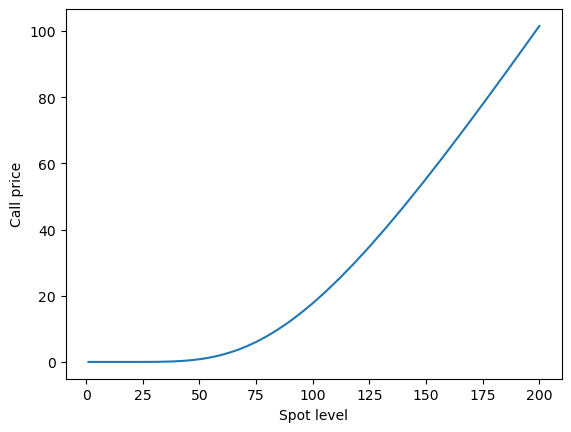

In [6]:
spot_range = np.linspace(S*0.01, S*2, 100)

call_option = AmericanOption(spot_range, K, r, sigma, T, q, option_type='call')
call_price = binomial_tree.vanilla_option_price(call_option)

plt.plot(spot_range, call_price)
plt.xlabel('Spot level')
plt.ylabel('Call price')
plt.show()

### Price vs Vol

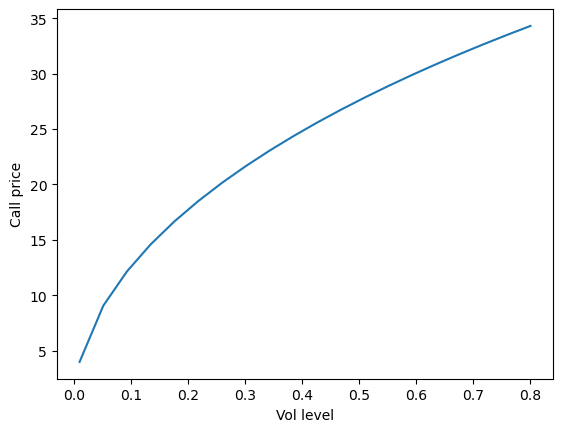

In [7]:
vol_range = np.linspace(0.01, 0.8, 20)

call_option = AmericanOption(S, K, r, vol_range, T, q, option_type='call')
call_price = binomial_tree.vanilla_option_price(call_option)

plt.plot(vol_range, call_price)
plt.xlabel('Vol level')
plt.ylabel('Call price')
plt.show()

### Price vs TTM

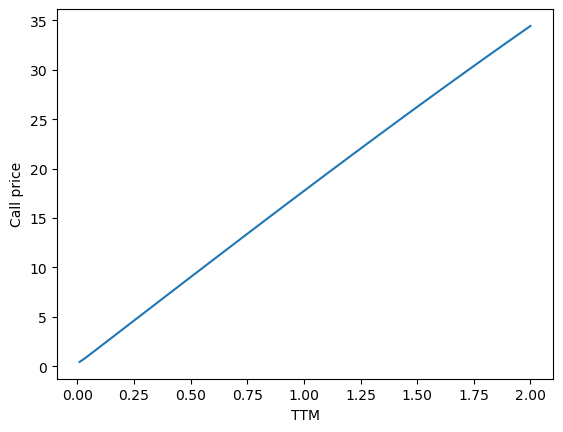

In [8]:
ttm_range = np.linspace(T*0.01, T*2, 100)

call_option = AmericanOption(S, K, r, sigma, ttm_range, q, option_type='call')
call_price = binomial_tree.vanilla_option_price(call_option)

plt.plot(ttm_range, call_price)
plt.xlabel('TTM')
plt.ylabel('Call price')
plt.show()

In [9]:
call_option = AmericanOption(S, K, r, sigma, T, q, option_type='call')
call_greeks = NumericalGreeks(call_option, binomial_tree.vanilla_option_price).greeks()

for i, val in call_greeks.items():
    print(i + ': ', round(val,2))

Delta:  0.59
Gamma:  0.01
Vega:  0.17
Theta:  -0.12
Rho:  0.08
Volga:  -0.84
Vanna:  0.08
Charm:  0.21


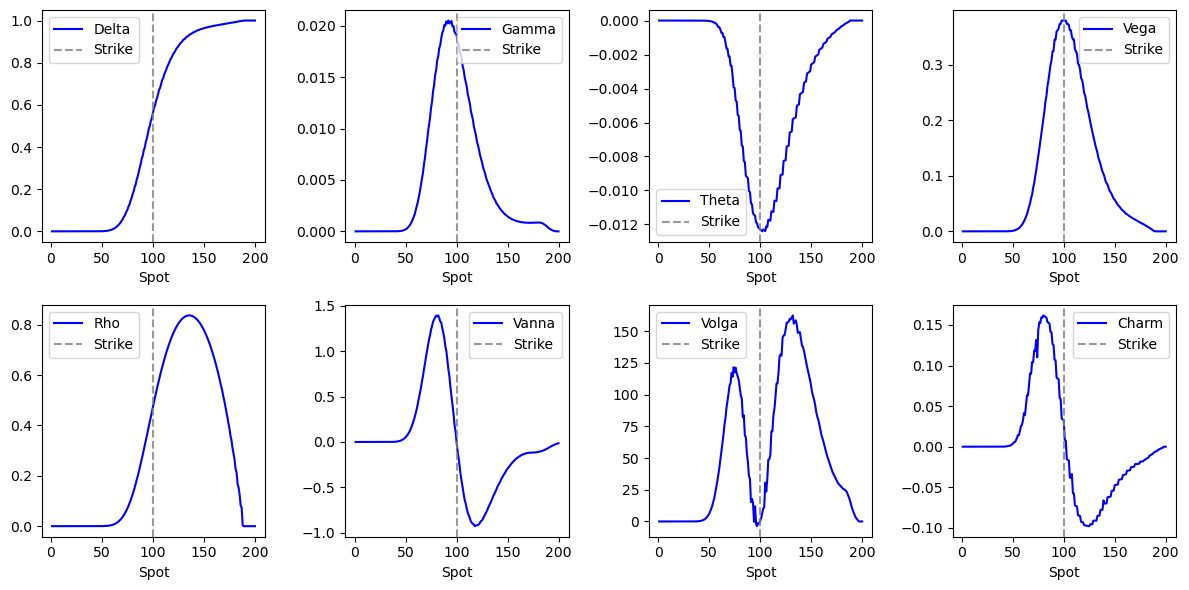

In [10]:
spot_range = np.linspace(start=S*0.01, stop=S*2, num=200)
metrics = ['Delta', 'Gamma', 'Theta', 'Vega', 'Rho', 'Vanna', 'Volga', 'Charm']

val = {j: [] for j in metrics}

for i in spot_range:
    option = AmericanOption(i, K, r, T, sigma, q, 'call')
    greeks = NumericalGreeks(option, binomial_tree.vanilla_option_price).greeks()
    for j in metrics:
        val[j].append(greeks[j])

plt.figure(figsize=(12,6))

for idx, i in enumerate(val):
    plt.subplot(2, 4, idx+1)
    plt.plot(spot_range, val[i], label=i, color='blue')
    plt.axvline(x=K, color='grey', linestyle='--', label='Strike', alpha=0.8)
    plt.xlabel('Spot')
    plt.legend()

plt.tight_layout()
plt.show()